In [1]:
import os, sys

import IPython.display as ipd

path= '/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation'
sys.path.append(path)


In [2]:
import gemmi
import matplotlib.pyplot as plt
import meteor
from occupancy import *
from plotting3d import *
%load_ext autoreload 
%autoreload 2

In [3]:
import reciprocalspaceship as rs
def struc2realspace(struc, hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(struc, high_resolution_limit=hs_limit)
    struc_vals=rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F","PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_real = np.fft.ifftn(struc_vals_grid).real
    return struc_vals_real

In [4]:
dataloc = "../synthetic_cistrans/"
pdbname_light = dataloc+"100ps.pdb"
struc_dark = gemmi.read_structure(pdbname_light)
struc_light = gemmi.read_structure(pdbname_light)
from meteor import sfcalc

# st_in = gemmi.read_structure('../tests/1orc.pdb')


# take space group and unit cell from Structure,

# and set size based on the specified minimal spacing

# grid.setup_from(st, spacing=0.6)

In [5]:
target_occ = 0.27
new_occ = 0.14
for x in struc_light[0].all():
    if np.round(x.atom.occ,2)==  target_occ:
        x.atom.occ=new_occ
    elif np.round(x.atom.occ,2) == 1-target_occ:
        x.atom.occ=1-new_occ
    else:
        pass
        # x.atom.occ=0.2
        

Text(0.5, 0, 'Occupancy')

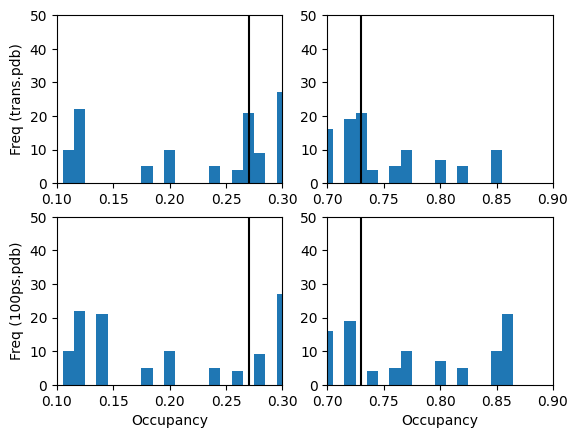

In [6]:
plt.close("all")
fig, axs = plt.subplots(2,2)
ax =axs[0,0]
alpha=0.27
bins = np.linspace(0.005,1.005,101)
for ax in axs.flat:
    ax.axvline(alpha,color="k")
    ax.axvline(1-alpha,color="k")
    ax.set_ylim(0,50)
    
ax =axs[0,0]
ax.hist([np.round(x.atom.occ,2) for x in struc_dark[0].all()], bins = bins)
ax.set_xlim(.1,.3)
ax.set_ylabel("Freq (trans.pdb)")

ax =axs[1,0]
ax.hist([np.round(x.atom.occ,2) for x in struc_light[0].all()], bins = bins)
ax.set_xlim(.1,.3)
ax.set_ylabel("Freq (100ps.pdb)")
ax.set_xlabel("Occupancy")

ax =axs[0,1]
ax.hist([np.round(x.atom.occ,2) for x in struc_dark[0].all()], bins = bins)
ax.set_xlim(.7,.9)

ax =axs[1,1]
ax.hist([np.round(x.atom.occ,2) for x in struc_light[0].all()], bins = bins)
ax.set_xlim(.7,.9)
ax.set_xlabel("Occupancy")

In [9]:
# frac_list, occ_mask=get_pos_from_pdb(st, search_occ=0.27)
# %matplotlib widget
# flist = frac_list.copy()
# flist[1] = 1-flist[1]
# # _ = mtz_comp(flist,occ_mask,  arr,extent=[1,0,0,1]) 
# # _ = mtz_comp(frac_list,occ_mask,  np.flip(arr,(0,)),extent=[1,0,0,1]) 
# _ = mtz_comp(frac_list,occ_mask,  np.flip(arr,(0,1,2)),extent=[0,1,1,0]) 

In [12]:
from generate_objects import get_pdb_pairs
pdb_pair = get_pdb_pairs("photolyase30")
pdb_pair = get_pdb_pairs("doeke")
pdb_pair = get_pdb_pairs("photolyase10")
pdb_pair = get_pdb_pairs("mpro")
pdb_pair = get_pdb_pairs("real_cistrans")
parent = "/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/"
fname_dark = f"{parent}synthetic_data/{pdb_pair[0]}.pdb"
fname_mix = f"{parent}synthetic_data/{pdb_pair[1]}.pdb"


In [13]:
from SFC_Torch import PDBParser

str = PDBParser(fname_mix)
p1_frac_coord = str.exp_sym(str.atom_pos_frac)
p1_coord = str.frac2orth(p1_frac_coord)
p1_ind = np.tile(np.arange(len(str.atom_pos)), len(str.operations))
p1_str = str.from_atom_slices(p1_ind)

p1_coord_flat = p1_coord.transpose(1, 0, 2).reshape(-1, 3)
p1_str.set_positions(p1_coord_flat)
len(str.atom_pos), len(p1_str.atom_pos)/4

(2277, 2277.0)

In [14]:
struc_dark = gemmi.read_structure(fname_dark)
struc_light = gemmi.read_structure(fname_mix)

print(struc_dark.spacegroup_hm)
print((struc_light.spacegroup_hm=="P 21 21 21"))

# print(len([atom for atom in struc_dark[0].all()]))
# print(len([atom for atom in struc_dark[0].all()]))
for idx in range(len(struc_dark.cell.images)):
    for cra in (struc_dark[0].all()):
        frac = struc_dark.cell.fractionalize(cra.atom.pos)
        atom_loc = np.array(struc_dark.cell.images[idx].apply(frac).tolist())
        break


P 21 21 21
True


In [22]:
density_dark = struc2realspace(struc_dark, 1.6, 0)
density_light = struc2realspace(struc_light, 1.6, 0)
f_dark = np.fft.fftn(density_dark)  
f_light = np.fft.fftn(density_light+)  

diff = density_light-density_dark

print(density_dark.shape, density_light.shape)

(100, 120, 144) (100, 120, 144)


In [23]:
%matplotlib widget

4
using the following for plot name:


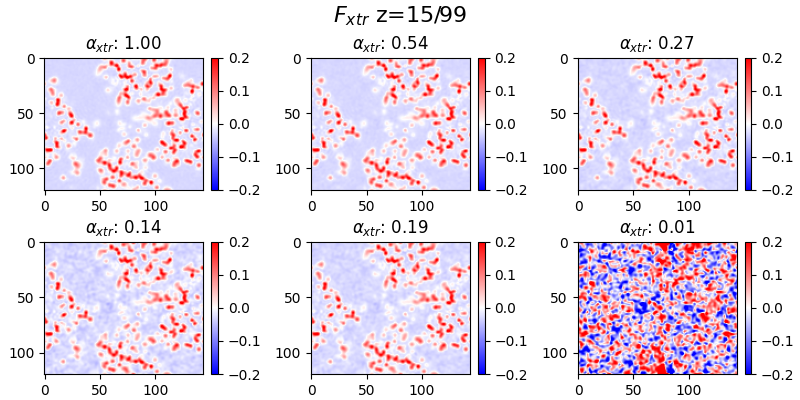

interactive(children=(IntSlider(value=15, description='f0', max=99), Output()), _dom_classes=('widget-interact…

In [30]:
imagetype = ""
alpha_xtrs_vis = np.array([1, alpha * 2, alpha, alpha / 2, 0.19, 0.01])
f_xtrs_vis = make_f_xtr(
    alpha_xtrs_vis, f_dark, f_light, np.angle(f_dark), version=1, noise_level=0
)
dens_xtrs_vis = np.array([np.fft.ifftn(f_xtr).real for f_xtr in f_xtrs_vis])
print(dens_xtrs_vis.ndim)
if dens_xtrs_vis.ndim==4:
    anim = show_xtrs( dens_xtrs_vis, alpha_xtrs_vis, density_dark, alpha, version="only", variant=imagetype, make_gif=False, )
elif dens_xtrs_vis.ndim==3:
    fig, axs = plt.subplots(2,3, figsize=(8,4),constrained_layout=True)
    steps = 1

    for ax, alpha_xtr, arr in zip(axs.flat, alpha_xtrs_vis,dens_xtrs_vis):

        raw = [r"$\alpha_{xtr}$",
               r"$\alpha_t$"]
        tit = f"{raw[0]}: {alpha_xtr:.2f}"
        ax.set_title(tit)
        diff = arr/np.max(arr)-obj0/np.max(obj0)
        vmax = np.max(diff)
        im = ax.imshow(diff, cmap="bwr",vmin=-vmax, vmax=vmax)
        plt.colorbar(im)
    plt.suptitle(r"$\frac{F_{xtr}}{\max_q(F_{xtr})} - \frac{F_0}{\max_q(F_0)}$")
    plt.show()    
        


In [63]:
def get_thresh(delta_obj, show=False):
    perc = np.percentile(np.abs(delta_obj),99.9)
    bins = np.logspace(-8,1)
    return perc
    if show:
        print("top top: ",perc)
        plt.figure()
        plt.hist(np.abs(delta_obj).flatten(), bins=bins)
        plt.axvline(perc)
        plt.xscale('log')
        plt.yscale('log')
        plt.show()
plt.close("all")

In [65]:
def compact_negsum(density_light, density_dark):
    f_dark = np.fft.fftn(density_dark)  
    f_light = np.fft.fftn(density_light)  
    
    title = "Negative Sum Explosion"
    alpha_invs = np.concatenate([
        np.arange(1, 8,0.8),
        np.arange(9, 50,5),
    ])
    alpha_invs = (np.arange(1,20)+1e-10)
    print(alpha_invs)
    alpha_xtrs_other = 2/alpha_invs
    # alpha_xtrs_other = np.sort(np.concatenate([alpha_xtrs, alpha_xtrs_other]))[::-1]
    # alpha_invs_other = 2/alpha_xtrs_other
    alpha_invs_other = alpha_invs
    delta_obj = density_light -  density_dark
    mask_thresh = get_thresh(delta_obj, show=True)
    mask_pks_neg = (delta_obj)<-mask_thresh
    config = Config("", alpha)

    f_xtrs_other = make_f_xtr(alpha_xtrs_other, f_dark, f_light, np.angle(f_dark),  version=1, noise_level = 0)
    _, neg_sum = marius(f_xtrs_other, mask_pks_neg)
    n_largest = 7
    n_more = 4

    neg_sum_explosion(alpha_invs_other, neg_sum, config, None, n_more, title=title)
    from compare_conds import get_intersect_and_angle
    intersection, angle = get_intersect_and_angle(alpha_invs_other, neg_sum, n_largest)
    # plt.xlim(0,7)
    # plt.ylim(-50,400)


In [34]:
# real_cistrans
search_occs=list([[0.225,0.275,0.615,0.665],[0.115,0.775]])
search_occs=list([[0.225,0.665],[0.275,0.615]])
search_occs=list([[0.225,],[0.665]])
search_occs=list([[0.665],[0.615]])
search_occs=list([[0.225,0.665],[0.275,0.615]])

Occurences 0.445 0
Occurences 0.575 0


interactive(children=(IntSlider(value=0, description='f0', max=215), Output()), _dom_classes=('widget-interact…

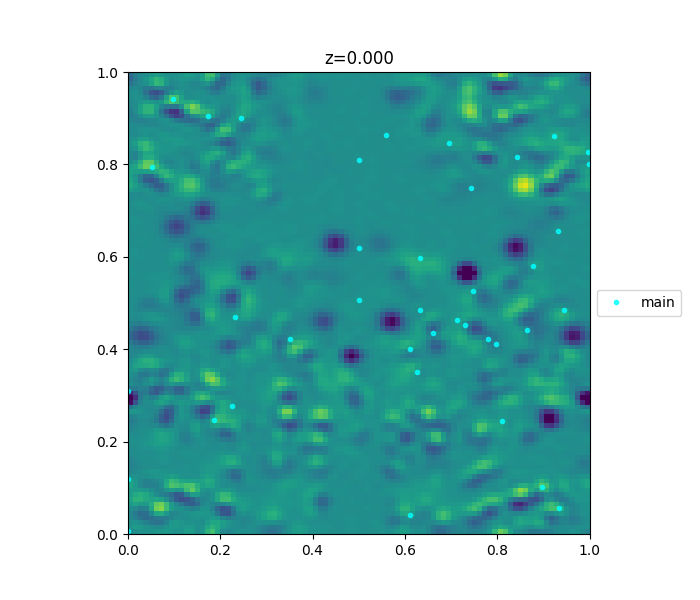

In [20]:
search_occs=list([[0.445],[0.575]])

frac_list_light, occ_mask=get_pos_from_pdb(struc_light, search_occ=search_occs)
# search_occs= list([[0.115],[0.775]])
_ = mtz_comp(frac_list_light,occ_mask,  np.flip(diff,(0,1,2)  ),extent=[0,1,1,0]) 

Occurences 0.115 0
Occurences 0.775 0


interactive(children=(IntSlider(value=0, description='f0', max=215), Output()), _dom_classes=('widget-interact…

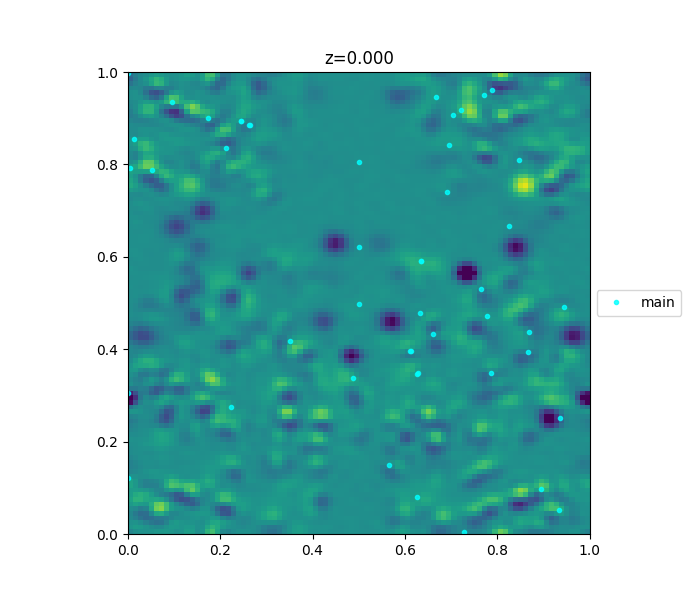

In [21]:
# search_occs=list([[0.225,],[0.665]])
search_occs= list([[0.115],[0.775]])


frac_list_dark, occ_mask=get_pos_from_pdb(struc_dark, search_occ=search_occs)
_ = mtz_comp(frac_list_dark,occ_mask,  np.flip(diff,(0,1,2)  ),extent=[0,1,1,0]) 
# plt.close("all")
# _ = mtz_comp(frac_list_dark,occ_mask,  np.flip(diff,(0,1,2)  ),extent=[0,1,1,0]) 
# _ = mtz_comp(frac_list,occ_mask,  np.flip(np.abs(diff)>0.08,(0,1,2)),extent=[0,1,1,0]) 

In [22]:
0.115+0.775

0.89

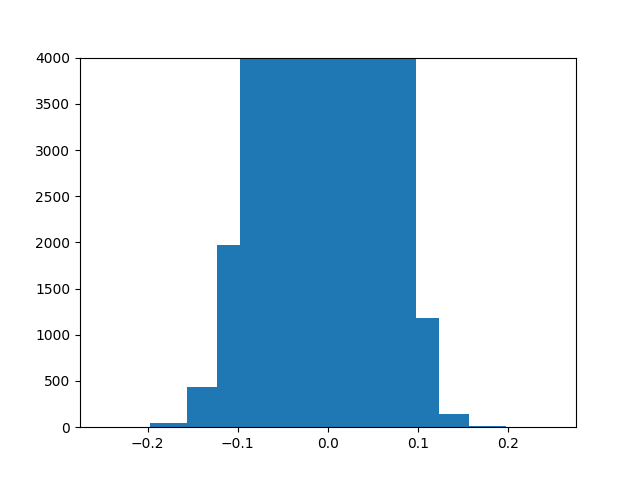

In [23]:
bins = np.logspace(-5,0,50)/4
bins_neg = -1*bins[::-1]
bins = np.concatenate((bins_neg,bins))
plt.figure()
plt.hist(diff.flatten(), bins=bins)
plt.ylim(0,4_000)
plt.show()


In [24]:
# _ = mtz_comp(frac_list,occ_mask,  np.flip(arr,(0,1,2)),extent=[0,1,1,0]) 

 [0.445 0.565] [0.285 0.365 0.375 0.425 0.455 0.475 0.495 0.515 0.535 0.555 0.585 0.635
 0.645 0.725 1.005]


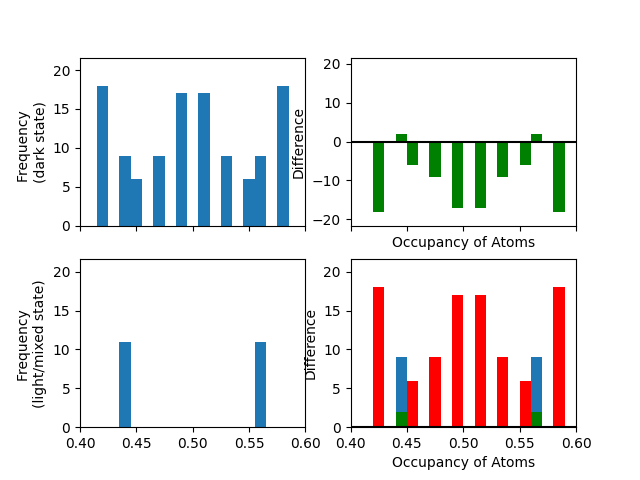

In [67]:
plt.close("all")
def plot_hists(struc_light, struc_dark, title = "",make_four=True):
    alpha=0.27
    smallest = 0
    largest = 1
    step = 0.01
    lim  = None
    bins = np.arange(-step/2,1+3/2*step,step)
        
        
    if make_four:
        fig, axs = plt.subplots(2,2,  sharex=True)
    else:
        fig, axs = plt.subplots(3,1,  sharex=True, tight_layout=True)
    fig.suptitle(title)
    ax =axs[0,0] if axs.ndim ==2 else axs[0]
    vals_dark, _, _ = ax.hist([x.atom.occ for x in struc_dark[0].all()], bins = bins)
    ax.set_ylabel("Frequency  \n(dark state)")
    lim = np.max(vals_dark[:-1])*1.2 if lim is None else lim
    ax.set_ylim(0,lim)
    ax.set_xlim(0.4,.6)
    
    ax =axs[1,0] if axs.ndim ==2 else axs[1]
    vals_light, _, _ = ax.hist([x.atom.occ for x in struc_light[0].all()], bins = bins)
    ax.set_ylim(0,lim)
    
    ax.axvline(0.115,color="k")
    ax.set_ylabel("Frequency \n(light/mixed state)")

    diff = vals_light-vals_dark
    bin_diff = bins[1]-bins[0]
    # show_bins = bins[1:] + bin_diff
    show_bins = bins[:-1] + bin_diff

    ax =axs[0,1] if axs.ndim ==2 else axs[2]
    ax.set_ylim(-lim,lim)
    ax.bar(show_bins, diff, width = bin_diff,color='green', label= "difference")
    print(title, show_bins[diff>1], show_bins[diff<-1])

    ax.axhline(0, color="black")
    ax.set_ylabel("Difference")
    ax.set_xlabel("Occupancy")
    ax.set_xlabel("Occupancy of Atoms")

    if axs.ndim==2:
        ax =axs[1,1]
        ax.set_ylim(0,lim)
        ax.bar(show_bins, vals_dark, width = bin_diff, label= "difference")
        ax.bar(show_bins, diff, width = bin_diff,color='green', label= "difference")
        ax.bar(show_bins[::-1], -1*diff, width = bin_diff,color='red', label="'inverted' difference")
        # ax.legend()

    ax.axhline(0, color="black")
    ax.set_ylabel("Difference")
    ax.set_xlabel("Occupancy")
    ax.set_xlabel("Occupancy of Atoms")
    return fig
_ = plot_hists(struc_light, struc_dark,)

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_22014/3432472460.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(3,1,  sharex=True, tight_layout=True)


MPRO (meteor) [0.105 0.205 0.305 0.505 0.605 0.705 0.805 0.905 1.005] [0.195 0.215 0.265 0.315 0.335 0.355 0.385 0.395 0.455 0.485 0.495 0.515
 0.525 0.555 0.615 0.625 0.655 0.675 0.695 0.745 0.755 0.795 0.815]
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19.]
using the following for plot name:
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/plots/_negsumexplosion.png
saving in /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../tex/figs/_negsumexplosion.pdf
intersection point, 0.272 (7.36)


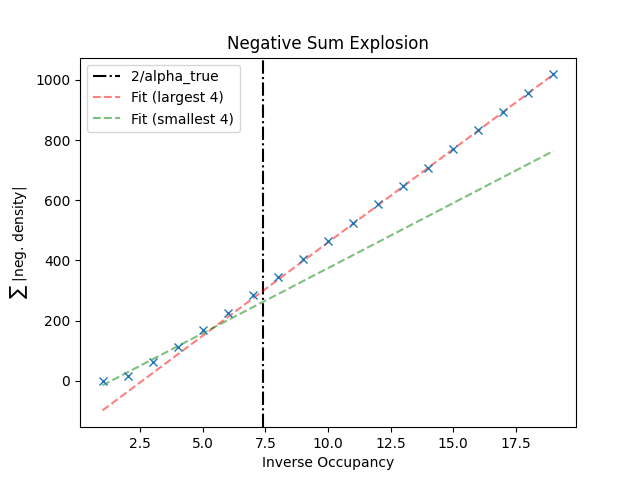

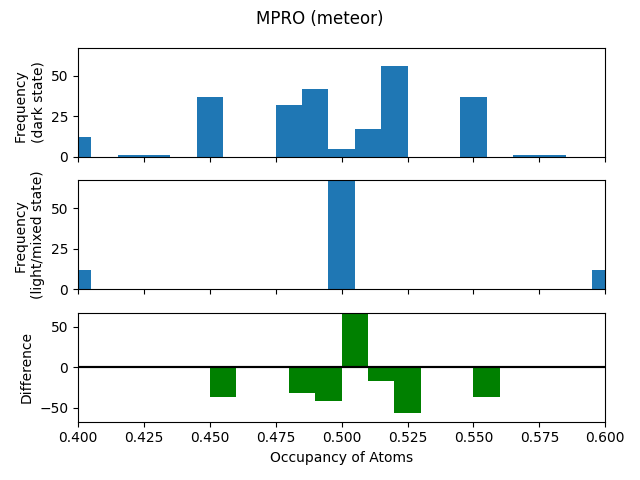

In [71]:
from plotting3d import save_fig 
names = ["photolyase10", "photolyase30" ,"real_cistrans" ,"doeke" ,"mpro" ]
names_dict = {
    # "photolyase10": "Photolyase 10 ns", 
    # "photolyase30": "Photolyase 30 ns", 
    # "synthetic_cistrans": "rsEGFP2 (synth)",
    # "real_cistrans": "rsEGFP2 (meteor)",
    "mpro": "MPRO (meteor)",
    # "doeke": "EFX protein (Doeke)",
}
for name in names_dict.keys():    
    pdb_pair = get_pdb_pairs(name)
    parent = "/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/"
    fname_dark = f"{parent}synthetic_data/{pdb_pair[0]}.pdb"
    fname_mix = f"{parent}synthetic_data/{pdb_pair[1]}.pdb"
    struc_dark = gemmi.read_structure(fname_dark)
    struc_light = gemmi.read_structure(fname_mix)
    density_dark = struc2realspace(struc_dark, 1.6, 0)
    density_light = struc2realspace(struc_light, 1.6, 0)

    fig = plot_hists(struc_light, struc_dark,make_four=False, title=names_dict[name])
    fname = "pdbhist_"+name
    # save_fig(fig,fname)
    compact_negsum(density_light, density_dark) 
    plt.show()

In [27]:
vals_light[-1], vals_dark[-1]
# pdb_pair

NameError: name 'vals_light' is not defined

In [ ]:
diff[diff<0], diff[diff>0]

In [28]:
0.225 + 0.665,0.275+0.615,[0.115+0.775]

(0.89, 0.89, [0.89])